# Initial test of loading cropping and manipulating videos from Tim's data

In [81]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchcodec.decoders import VideoDecoder
from torchvision.transforms import v2
import matplotlib.patches as patches
import sys
import h5py
import re
import os

sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')

import preprocessing.video_preprocessing_utils as video_utils

## Look at some example frames

In [6]:
video_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_side_trial111_date_2022_12_06_time_12_32_50.mp4'

In [7]:
decoder = VideoDecoder(video_path)

In [9]:
raw_frame = decoder.get_frame_at(174)

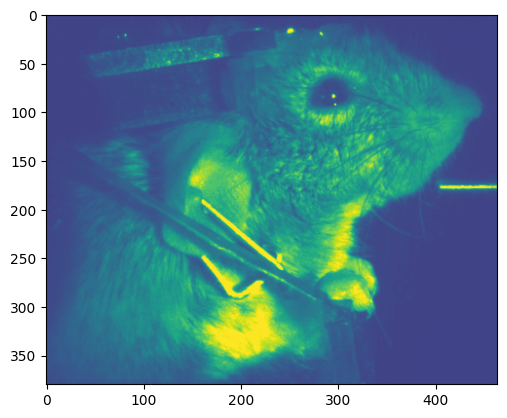

In [11]:
raw_img = raw_frame.data.permute(1, 2, 0).numpy()
plt.imshow(raw_img[:,:,0])

## Look at transformation pipeline

In [12]:
config_path = '../configs/ae_config.json'
with open(config_path, 'r') as f:
    config = json.load(f)
print("Config loaded:", json.dumps(config, indent=2))

Config loaded: {
  "metadata_config": {
    "behavior_channel_map": {
      "outcome": 0,
      "trial_type": 1,
      "early_lick_sample": 2,
      "early_lick_delay": 3,
      "airpuff": 4,
      "autowater": 5,
      "water_volume": 6,
      "trial_length": 7,
      "z_pos": 8,
      "laser_power": 9,
      "n_licks": 11,
      "protocol": 12,
      "reaction_time": 14,
      "sample_start": 15,
      "delay_start": 16,
      "go_time": 17,
      "reward_time": 18,
      "freewater_outcome": 19,
      "reward1": 20
    },
    "stratification_columns": [
      "outcome",
      "trial_type",
      "airpuff"
    ],
    "split_random_seed": 42
  },
  "dataset": {
    "frame_selection_method": "frame_subsample",
    "train_nth_frame": 10,
    "subtract_mean_frame": true,
    "mean_frame_path": null
  },
  "data": {
    "image_height": 120,
    "image_width": 112,
    "crop_top": 0,
    "crop_bottom": 80,
    "crop_left": 100,
    "crop_right": 0
  },
  "model": {
    "num_blocks": 2,
   

In [82]:
transforms = video_utils.get_video_transforms(config)

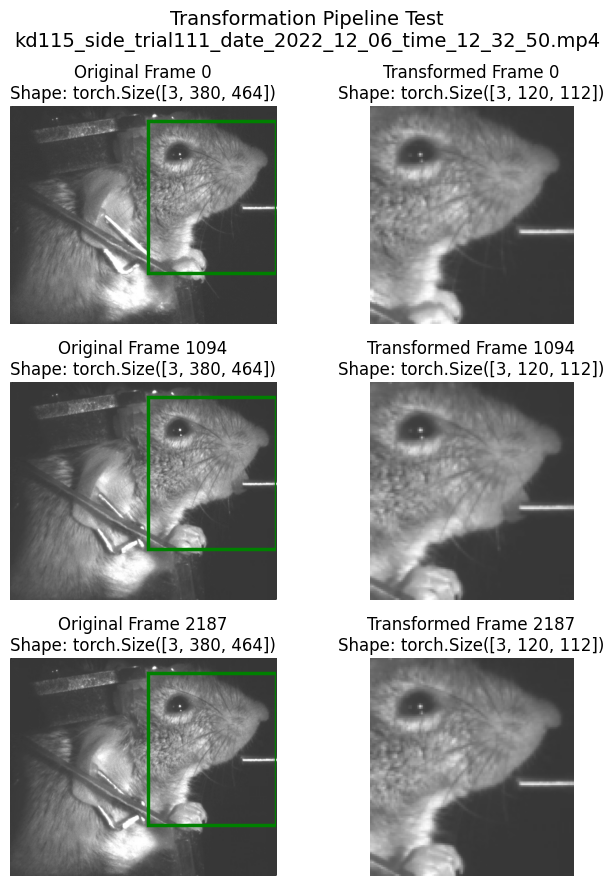

In [83]:
num_frames = len(decoder)
sample_indices = [0, num_frames // 2, num_frames - 1]

# 3. Setup Matplotlib figure
fig, axes = plt.subplots(nrows=len(sample_indices), ncols=2, figsize=(7, 3 * len(sample_indices)))
fig.suptitle(f"Transformation Pipeline Test\n{video_path.split('/')[-1]}", fontsize=14)

for row_idx, frame_idx in enumerate(sample_indices):
    # --- GET ORIGINAL FRAME ---
    # torchcodec returns a tensor of shape (C, H, W) in uint8 [0, 255]
    orig_tensor = decoder.get_frame_at(frame_idx).data
    
    # --- APPLY TRANSFORM ---
    # Your v2 pipeline returns shape (C, H, W) in float32 [0.0, 1.0]
    trans_tensor = transforms(orig_tensor)
    
    # --- PREPARE FOR MATPLOTLIB ---
    # Matplotlib expects images in (H, W, C) format, so we permute the axes.
    orig_img = orig_tensor.permute(1, 2, 0).numpy()
    trans_img = trans_tensor.permute(1, 2, 0).numpy()
    
    # Plot Original
    ax_orig = axes[row_idx, 0]
    ax_orig.imshow(orig_img)
    ax_orig.set_title(f"Original Frame {frame_idx}\nShape: {orig_tensor.shape}")
    ax_orig.axis('off')

    H, W, _ = orig_img.shape
    c_top = config['data']['crop_top']
    c_bot = config['data']['crop_bottom']
    c_left = config['data']['crop_left']
    c_right = config['data']['crop_right']
    
    # Calculate dimensions of the bounding box
    box_width = W - c_left - c_right
    box_height = H - c_top - c_bot
    
    # Create the rectangle patch
    rect = patches.Rectangle(
        (c_left, c_top),      # (x, y) of the top-left corner
        box_width, 
        box_height, 
        linewidth=2.5, 
        edgecolor='green', 
        facecolor='none',     # Don't fill the box
        linestyle='-'        # Dashed line makes it easier to see over the image
    )
    # Add it to the original axis
    ax_orig.add_patch(rect)
    
    # Plot Transformed
    ax_trans = axes[row_idx, 1]
    ax_trans.imshow(trans_img, cmap='gray') # Matplotlib handles float32 [0, 1] natively
    ax_trans.set_title(f"Transformed Frame {frame_idx}\nShape: {trans_tensor.shape}")
    ax_trans.axis('off')

plt.tight_layout()
plt.savefig('/home/kurgyis/Research/VideoAnalysisTools/figures/transformation_pipeline_test.png', dpi=300, bbox_inches='tight')
plt.show()

## Preprocessing videos to h5py

### Run preprocessing (takes 20 mins, there is script for this)

In [ ]:
video_utils.convert_videos_to_hdf5(video_folder=config['data']['data_path'], transform=transforms,
                       h5_filename='kd115_twNew_20221206_115814_side_newcrop.h5',
                       save_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/')

### Load preprocessed h5py

In [71]:
h5_session_path = '/home/kurgyis/Research/VideoAnalysisTools/data/kd115_twNew_20221206_115814/kd115_twNew_20221206_115814_side_newcrop.h5'

dataset = h5py.File(h5_session_path, 'r')

In [72]:
random_inds = np.random.choice(len(dataset['frames']), size=32, replace=False)
batch = np.stack(dataset['frames'][np.sort(random_inds)], axis=0)

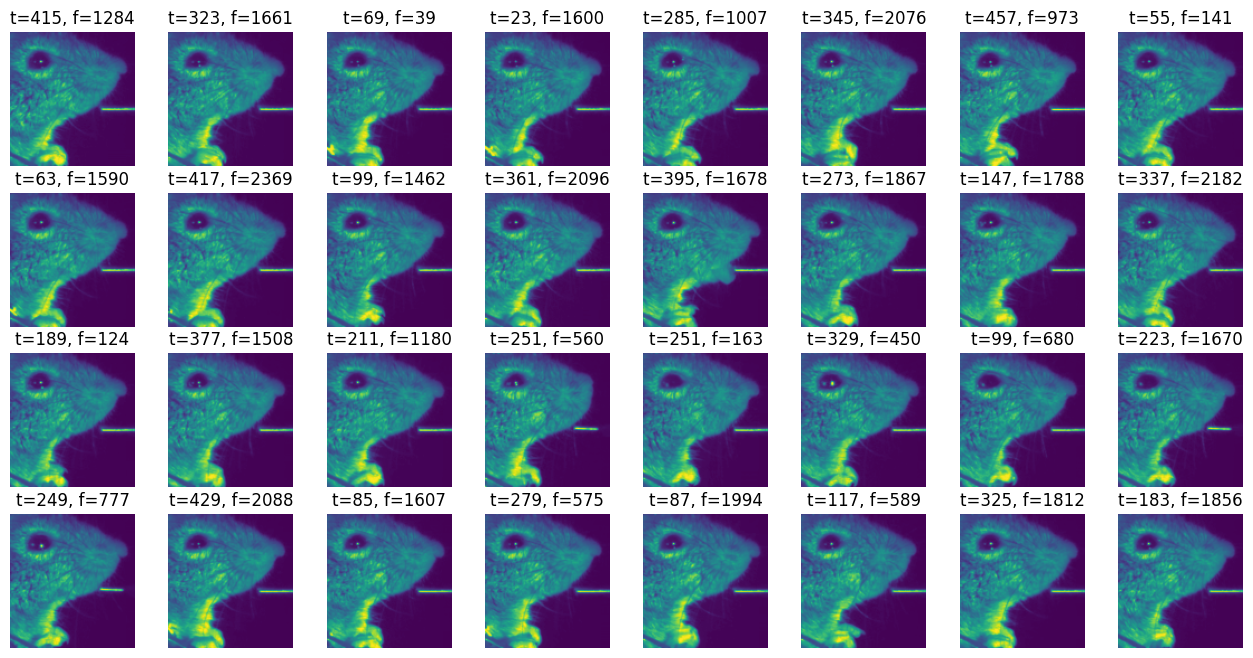

In [73]:
plt.subplots(4,8, figsize=(16,8))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.axis('off')
    plt.imshow(batch[i][0])
    plt.title(f"t={dataset['trial_ids'][random_inds[i]]}, f={dataset['id_within_trial'][random_inds[i]]}")

## Look at the timing between video and calcium data

In [74]:
sess = 'kd115_twNew_20221206_115814'

In [80]:
bpod_path = '/home/kurgyis/Research/SpatialTranscriptomics/data/2p/kd115/kd115_twNew_20221206_115814.bpod.npy'

bpod_data = np.load(bpod_path, allow_pickle=True)

In [76]:
ops_path = '/home/kurgyis/Research/SpatialTranscriptomics/data/2p/kd115/kd115_twNew_20221206_115814.0.ops.npy'

ops_data = np.load(ops_path, allow_pickle=True).item()

In [77]:
ca_n_frames = ops_data['frames_per_file']
ca_trial_name_list = [f.split('/')[-1] for f in ops_data['filelist']]
ca_trial_inds =  np.array([bpod_data[1].index(b) for b in ca_trial_name_list])

ca_trial_inds

video_trial_ids = np.array([int(f.split('_trial')[1].split('_date')[0]) for f in np.array(bpod_data[2])[ca_trial_inds][:,0]])


In [78]:
video_frames_per_trial = np.array([np.where(dataset['trial_ids'] == tid)[0].shape[0] for tid in video_trial_ids])

Text(0.5, 1.0, 'Video vs Calcium Frame Timing Comparison\nkd115_twNew_20221206_115814\n Ca_HZ = 29.1, Video_HZ = 200')

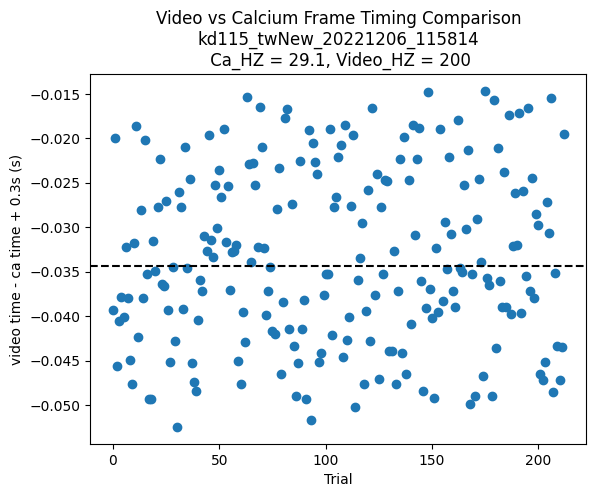

In [79]:
video_hz = 200
ca_hz = 29.1
plt.plot(video_frames_per_trial/video_hz - ca_n_frames/ca_hz + 0.3,'o')
plt.axhline(-1/ca_hz, color = 'k', linestyle = '--')
plt.xlabel('Trial')
plt.ylabel('video time - ca time + 0.3s (s)')
plt.title('Video vs Calcium Frame Timing Comparison\n%s\n Ca_HZ = 29.1, Video_HZ = 200' % sess)
#plt.savefig(figfolder + '%s_video_vs_ca_timing_comparison.png' % sess, dpi=300)